### Question 1a)

### Team Mean Skill Distribution

I am choosing to assign each teams skill from a normal distribution, which mathematically is:

$$
\mu_i \sim \mathcal{N}(\mu_0, \tau^2)
$$

where:
- $\mu_i$ is the mean skill of team $i$
- $\mu_0$ is the league-wide average skill level
- $\tau^2$ controls how much team skill varies across the league

For this simulation, I assume:

$$
\mu_i \sim \mathcal{N}(50, 10^2)
$$

This means that the average team skill is centered at 50, and most teams fall within about 10 skill points of that average, with a few stronger or weaker outliers. This distribution will work much better for some sports models than others. For example, I'm guessing it wouldn't work as well with the NBA or NFL, as having a draft incentivizes bad teams to tank, which means there is a much bigger gap between the bottom 6 teams and the top 6 teams than something like European football, where teams are trying to win every game they can. This is why to try and show the plausibility of this distribution I am going to compare the sample distribution to the premier league distribution from this season (as of April 5th). I'm also choosing this season's premier league table as I feel like there has been a lot of discussion about how in the prem, anyone can beat anyone and anyone can lose to anyone, and that there have really only been 2 elite teams this season, if you can even say city has been elite. 

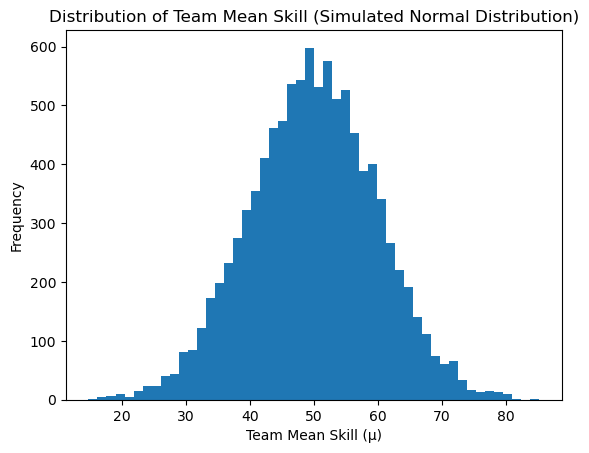

In [2]:
# Modeling the Normal Distribution

import numpy as np
import matplotlib.pyplot as plt

# Set parameters
mu_0 = 50
tau = 10

# Generate samples
samples = np.random.normal(mu_0, tau, 10000)

# Plot histogram
plt.figure()
plt.hist(samples, bins=50)

# Labels + title
plt.xlabel("Team Mean Skill (μ)")
plt.ylabel("Frequency")
plt.title("Distribution of Team Mean Skill (Simulated Normal Distribution)")

plt.show()

A simulated version of the normal distribution

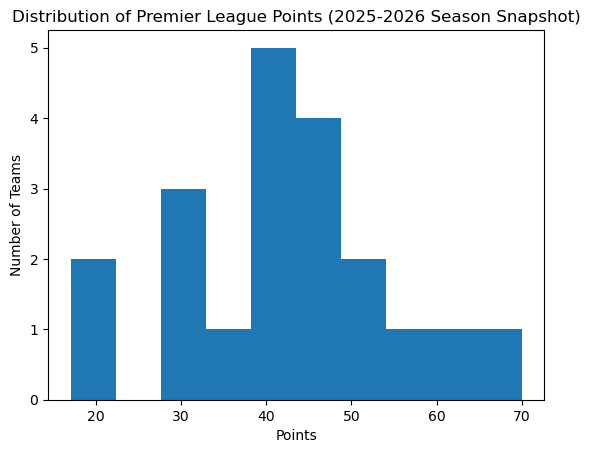

In [3]:
# Modeling the Premier League distribution from this season

# Points from the table
points = [
    70, 61, 55, 54, 49, 48, 46, 46, 44, 43,
    43, 42, 42, 39, 33, 32, 30, 29, 20, 17
]

# Plot histogram
plt.figure()
plt.hist(points, bins=10)

# Labels + title
plt.xlabel("Points")
plt.ylabel("Number of Teams")
plt.title("Distribution of Premier League Points (2025-2026 Season Snapshot)")

plt.show()

A 10 bin distribution of the 2025-26 premier league season point totals, to see if it somewhat resembles a normal distribution

### Comparing Simulated Skill to Real Data

To compare the simulated normal distribution with real-world Premier League performance, I standardized both datasets using z-scores:

$$
z = \frac{x - \mu}{\sigma}
$$

This transformation rescales both datasets so they have mean 0 and standard deviation 1. This allows for a direct comparison of their shapes, even though the original values (simulated skill vs. points) are on different scales.

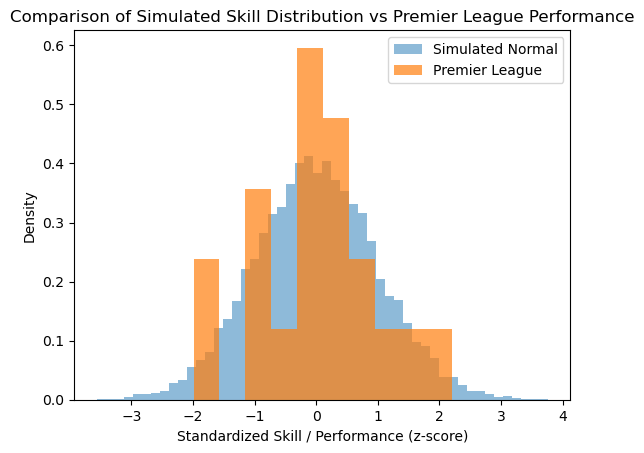

In [5]:
## Z scores Code

# Simulated data
mu_0 = 50
tau = 10
simulated = np.random.normal(mu_0, tau, 10000)

# Premier League points
points = np.array([
    70, 61, 55, 54, 49, 48, 46, 46, 44, 43,
    43, 42, 42, 39, 33, 32, 30, 29, 20, 17
])

# Normalize both (z-score)
sim_z = (simulated - np.mean(simulated)) / np.std(simulated)
points_z = (points - np.mean(points)) / np.std(points)

# Plot both
plt.figure()

plt.hist(sim_z, bins=50, density=True, alpha=0.5, label="Simulated Normal")
plt.hist(points_z, bins=10, density=True, alpha=0.7, label="Premier League")

plt.xlabel("Standardized Skill / Performance (z-score)")
plt.ylabel("Density")
plt.title("Comparison of Simulated Skill Distribution vs Premier League Performance")

plt.legend()
plt.show()

Standardized Z-score for the premier league and the simulated normal distribution

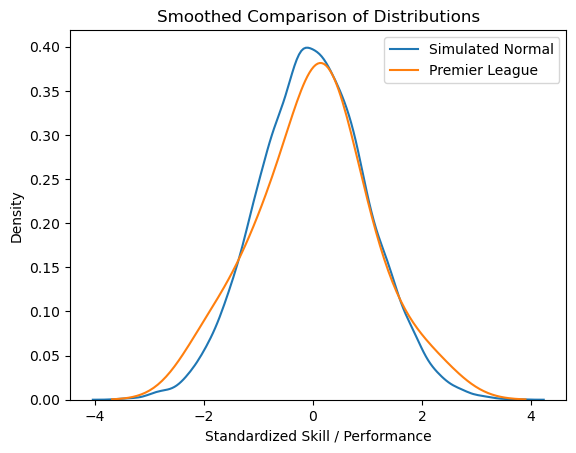

In [6]:
import seaborn as sns

plt.figure()

sns.kdeplot(sim_z, label="Simulated Normal")
sns.kdeplot(points_z, label="Premier League")

plt.xlabel("Standardized Skill / Performance")
plt.ylabel("Density")
plt.title("Smoothed Comparison of Distributions")

plt.legend()
plt.show()

After standardizing, I visualized both distributions using kernel density estimates (KDEs). A KDE provides a smooth approximation of the underlying distribution by placing a small Gaussian curve around each data point and summing them. This results in a continuous curve that is easier to interpret than a histogram and does not depend on bin choices. While my zscore histogram has some overlap between the distributions, the KDE's highlight it much better, with the normal distribution and the premier league distribution looking very similar.

### 1B

In [9]:
import pandas as pd
# Number of teams
N = 64

# Parameters from 1(a)
mu_0 = 50
tau = 10

# Sample mean skill
mu = np.random.normal(mu_0, tau, N)

# Variability, making it so that better teams are more consistent while worse teams have more variability and are more unpredictabloe
sigma = 12 - 0.1 * mu

# Create DataFrame
teams_df = pd.DataFrame({
    "team_id": range(1, N + 1),
    "mu": mu,
    "sigma": sigma
})

teams_df.head()

,team_id,mu,sigma
0,1,37.543686,8.245631
1,2,58.088547,6.191145
2,3,27.317301,9.268270
3,4,46.384467,7.361553
4,5,52.837431,6.716257


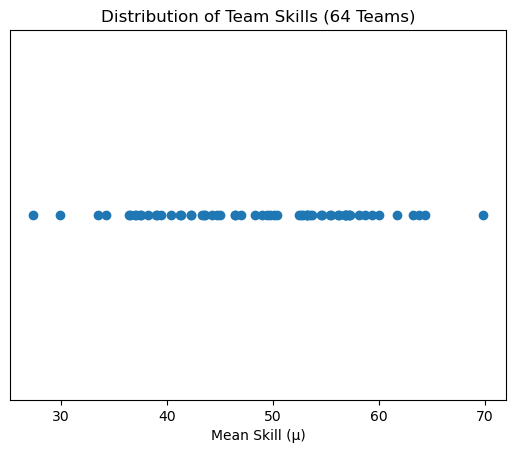

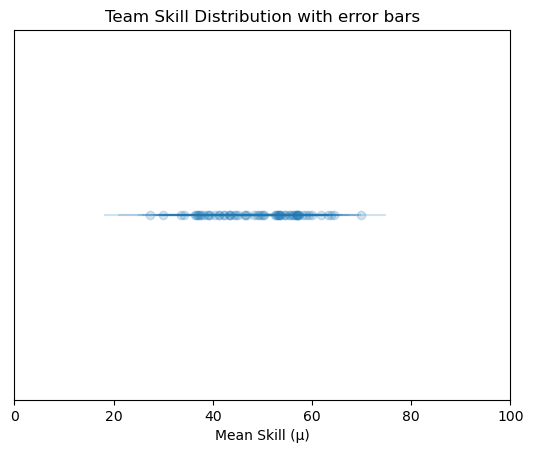

In [10]:
import matplotlib.pyplot as plt

plt.figure()

# Scatter points
plt.scatter(teams_df["mu"], np.zeros(N))

# Labels + title
plt.xlabel("Mean Skill (μ)")
plt.yticks([])  # removes useless y-axis
plt.title("Distribution of Team Skills (64 Teams)")

plt.show()

plt.figure()

plt.errorbar(
    teams_df["mu"],
    np.zeros(N),
    xerr=teams_df["sigma"],
    fmt='o',
    alpha=0.2
)
plt.xlim(0, 100) 
plt.xlabel("Mean Skill (μ)")
plt.yticks([])
plt.title("Team Skill Distribution with error bars")

plt.show()

In this distribution, teams are clustered in the center, with different sections of clusters. There are also a few teams on the end who are outliers. There is a huge amount of variation in the team skill distribution as the error bars are constant and go throughout the whole graph essnetially, although on the ends and especially at the top the line isn't as thick, meaning there is less variation for teams vs the absolute best or absolute worst teams. 

### 1c

In [13]:
def play_game(teamA, teamB, rng):
    """
    Simulate one game between two teams.

    Parameters:
        teamA, teamB: rows from teams_df containing at least
                      'team_id', 'mu', and 'sigma'
        rng: numpy random number generator

    Returns:
        dict with team ids, sampled performances, and winner id
    """
    perfA = rng.normal(teamA["mu"], teamA["sigma"])
    perfB = rng.normal(teamB["mu"], teamB["sigma"])

    if perfA > perfB:
        winner = teamA["team_id"]
    else:
        winner = teamB["team_id"]

    return {
        "teamA_id": teamA["team_id"],
        "teamB_id": teamB["team_id"],
        "teamA_perf": perfA,
        "teamB_perf": perfB,
        "winner_id": winner
    }

In [14]:
rng = np.random.default_rng(55)

teamA = teams_df.iloc[0]
teamB = teams_df.iloc[1]


print("Team A")
print(teamA)
print()
print("Team B")
print(teamB)


results = []
for game_num in range(100):
    result = play_game(teamA, teamB, rng)
    result["game_num"] = game_num + 1
    results.append(result)

results_df = pd.DataFrame(results)
print(results_df)

results_df["winner_id"].value_counts()

Team A
team_id     1.000000
mu         37.543686
sigma       8.245631
Name: 0, dtype: float64

Team B
team_id     2.000000
mu         58.088547
sigma       6.191145
Name: 1, dtype: float64
    teamA_id  teamB_id  teamA_perf  teamB_perf  winner_id  game_num
0        1.0       2.0   44.488662   39.663010        1.0         1
1        1.0       2.0   35.028571   67.065014        2.0         2
2        1.0       2.0   27.286438   58.417982        2.0         3
3        1.0       2.0   49.910992   50.856022        2.0         4
4        1.0       2.0   44.227773   69.844900        2.0         5
..       ...       ...         ...         ...        ...       ...
95       1.0       2.0   41.182126   63.067351        2.0        96
96       1.0       2.0   33.625744   50.120981        2.0        97
97       1.0       2.0   28.897060   59.389977        2.0        98
98       1.0       2.0   52.983236   56.550712        2.0        99
99       1.0       2.0   21.348827   54.595979        2.0      

winner_id
2.0    94
1.0     6
Name: count, dtype: int64

These 2 teams are very different in their skill level, with team a being one of the worst in our sample and team b being one of the best. Comparing it to college basketball, this is like the difference of a 14 seed vs a 3 seed in the tournament, which historically has happened about 14% of the time, but if you look at more recently in the past 3 years/the NIL era, it has happened 1/12 times, or .083, pretty close to our .07. 

### 1D

In [17]:
def build_seed_order(n):
    """
    Recursively build the standard fixed bracket seed order for n seeds.

    Examples:
    n = 2  -> [1, 2]
    n = 4  -> [1, 4, 2, 3]
    n = 8  -> [1, 8, 4, 5, 2, 7, 3, 6]
    """
    order = [1, 2]

    while len(order) < n:
        m = 2 * len(order) + 1
        new_order = []

        for seed in order:
            new_order.append(seed)
            new_order.append(m - seed)

        order = new_order

    return order

def run_knockout(teams, rng):
    """
    Run a 64-team seeded single-elimination tournament using a true fixed bracket.

    Parameters:
        teams: DataFrame with columns ['team_id', 'mu', 'sigma']
        rng: numpy random generator

    Returns:
        champion: winning team row
        match_log_df: DataFrame of all matches
    """

    # Sort teams by skill and assign seeds
    teams_sorted = teams.sort_values("mu", ascending=False).reset_index(drop=True).copy()
    teams_sorted["seed"] = teams_sorted.index + 1

    # Arrange teams into the true bracket order
    seed_order = build_seed_order(len(teams_sorted))
    teams_current = teams_sorted.set_index("seed").loc[seed_order].reset_index()

    match_log = []
    round_num = 1

    while len(teams_current) > 1:
        winners = []

        for i in range(0, len(teams_current), 2):
            teamA = teams_current.iloc[i]
            teamB = teams_current.iloc[i + 1]

            result = play_game(teamA, teamB, rng)
            winner_id = int(result["winner_id"])

            if winner_id == int(teamA["team_id"]):
                winner = teamA
            else:
                winner = teamB

            winner_seed = int(winner["seed"])
            upset = winner_seed > min(int(teamA["seed"]), int(teamB["seed"]))

            match_log.append({
                "round": round_num,
                "teamA_id": int(teamA["team_id"]),
                "teamB_id": int(teamB["team_id"]),
                "teamA_seed": int(teamA["seed"]),
                "teamB_seed": int(teamB["seed"]),
                "winner_id": winner_id,
                "winner_seed": winner_seed,
                "upset": upset
            })

            winners.append(winner)

        teams_current = pd.DataFrame(winners).reset_index(drop=True)
        round_num += 1

    champion = teams_current.iloc[0]
    match_log_df = pd.DataFrame(match_log)

    return champion, match_log_df

### 1E

In [19]:
rng = np.random.default_rng(55)

# Run tournament
champion, match_log_df = run_knockout(teams_df, rng)

# Champion
print("Champion:")
display(champion)

# Full match log
print("\nFull Match Log:")
display(match_log_df)

# Matches per round
print("\nMatches per round:")
display(match_log_df["round"].value_counts().sort_index())

# Total number of upsets
num_upsets = match_log_df["upset"].sum()
print(f"\nTotal number of upsets: {num_upsets}")

# Upsets by round
print("\nUpsets by round:")
display(match_log_df.groupby("round")["upset"].sum())

Champion:


seed        4.000000
team_id    55.000000
mu         63.196186
sigma       5.680381
Name: 0, dtype: float64


Full Match Log:


,round,teamA_id,teamB_id,teamA_seed,teamB_seed,winner_id,winner_seed,upset
0,1,52,3,1,64,52,1,False
1,1,47,37,32,33,37,33,True
2,1,44,9,16,49,44,16,False
3,1,7,23,17,48,7,17,False
4,1,60,24,8,57,60,8,False
...,...,...,...,...,...,...,...,...
58,4,43,35,2,23,43,2,False
59,4,46,56,3,27,46,3,False
60,5,2,55,9,4,55,4,False
61,5,43,46,2,3,43,2,False



Matches per round:


round
1    32
2    16
3     8
4     4
5     2
6     1
Name: count, dtype: int64


Total number of upsets: 16

Upsets by round:


round
1    6
2    6
3    3
4    0
5    0
6    1
Name: upset, dtype: int64

This is similar to a pretty boring march madness tournament, the tournament last year had upset counts by round of 6,4,1,0,2,1, which is actually one less than this one had. 

### 1F

In [22]:
# Number of tournament simulations
n_sims = 1000

# Sort teams by true skill (highest mu = rank 1)
teams_ranked = teams_df.sort_values("mu", ascending=False).reset_index(drop=True).copy()
teams_ranked["true_skill_rank"] = teams_ranked.index + 1

# Dictionary to map team_id -> true skill rank
rank_map = dict(zip(teams_ranked["team_id"], teams_ranked["true_skill_rank"]))

# Record champions
champion_ids = []

for sim in range(n_sims):
    rng = np.random.default_rng(sim)
    champion, match_log_df = run_knockout(teams_df, rng)
    champion_ids.append(int(champion["team_id"]))

# Convert to DataFrame
champions_df = pd.DataFrame({"champion_id": champion_ids})
champions_df["true_skill_rank"] = champions_df["champion_id"].map(rank_map)

# Championship counts by team
championship_counts = champions_df["champion_id"].value_counts().sort_index()

# Build summary table for all teams
team_summary = teams_ranked[["team_id", "mu", "sigma", "true_skill_rank"]].copy()
team_summary["championships"] = team_summary["team_id"].map(championship_counts).fillna(0).astype(int)
team_summary["championship_probability"] = team_summary["championships"] / n_sims

# Proportion of times the highest-mu team wins
top_team_id = teams_ranked.iloc[0]["team_id"]
top_team_win_rate = team_summary.loc[
    team_summary["team_id"] == top_team_id, "championship_probability"
].iloc[0]

print(f"Proportion of times the highest-mu team wins: {top_team_win_rate:.3f}")

# Top 5 teams by championship probability
top_5 = team_summary.sort_values("championship_probability", ascending=False).head(5)
print("\nTop 5 teams by championship probability:")
display(top_5)
(team_summary["championship_probability"] > 0).sum()

Proportion of times the highest-mu team wins: 0.650

Top 5 teams by championship probability:


,team_id,mu,sigma,true_skill_rank,championships,championship_probability
0,52,69.869184,5.013082,1,650,0.650
1,43,64.379425,5.562058,2,126,0.126
2,46,63.775874,5.622413,3,95,0.095
3,55,63.196186,5.680381,4,51,0.051
4,8,61.714456,5.828554,5,22,0.022


17

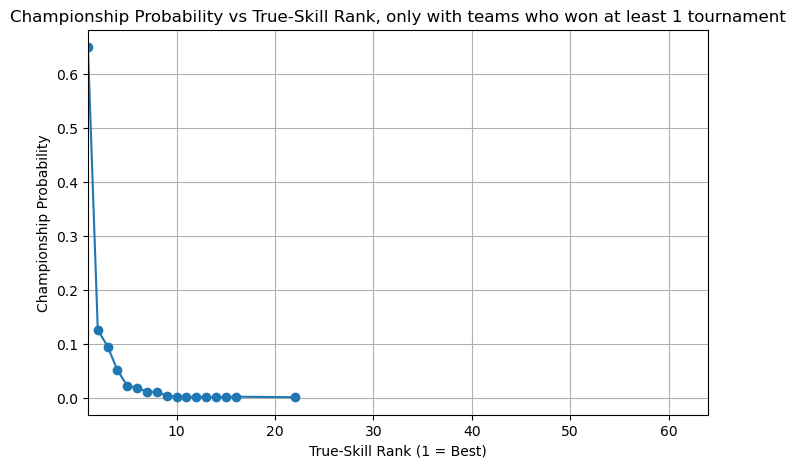

In [23]:
## Plot

plt.figure(figsize=(8, 5))

plot_df = team_summary[team_summary["championship_probability"] > 0]

plt.plot(
    plot_df["true_skill_rank"],
    plot_df["championship_probability"],
    marker="o"
)

plt.xlim(1, 64)
plt.xlabel("True-Skill Rank (1 = Best)")
plt.ylabel("Championship Probability")
plt.title("Championship Probability vs True-Skill Rank, only with teams who won at least 1 tournament")
plt.grid(True)
plt.show()

The one seed won the majority of the time, and the majority of the time someone else won, it was someone between 2-4.  Though it looks like everyone from 1-16 got at least one win, with seed 22 or 23 having 1 miracle tournament as well. 

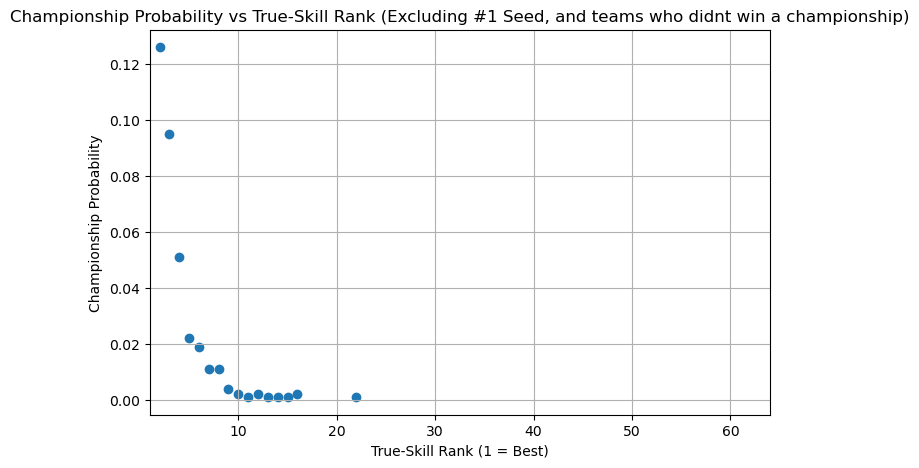

In [24]:
plt.figure(figsize=(8, 5))

plot_df_no1 = team_summary[
    (team_summary["championship_probability"] > 0) &
    (team_summary["true_skill_rank"] != 1)
]

plt.scatter(
    plot_df_no1["true_skill_rank"],
    plot_df_no1["championship_probability"]
)

plt.xlim(1, 64)
plt.xlabel("True-Skill Rank (1 = Best)")
plt.ylabel("Championship Probability")
plt.title("Championship Probability vs True-Skill Rank (Excluding #1 Seed, and teams who didnt win a championship)")
plt.grid(True)
plt.show()

I decided to make a graph without the 1 seed on it to better visualize the remaining teams who got at least 1 championship, which is cool because it shows that the 12 and 16 seeds actually got 2, which would've been impossible to see on the other graph. 

### 1G, I'm not doing 1E again im just gonna recreate the function and do part F

In [26]:
# Recreating function with random seeding
def run_knockout_random(teams, rng):
    """
    Run a 64-team single-elimination tournament with a random initial bracket.
    The bracket stays fixed after the initial shuffle (no reseeding).

    Parameters:
        teams: DataFrame with columns ['team_id', 'mu', 'sigma']
        rng: numpy random generator

    Returns:
        champion: winning team row
        match_log_df: DataFrame of all matches
    """

    # Sort by skill first so original seed numbers still mean something
    teams_sorted = teams.sort_values("mu", ascending=False).reset_index(drop=True)
    teams_sorted["seed"] = teams_sorted.index + 1

    # Randomize the initial bracket only
    random_order = rng.permutation(len(teams_sorted))
    teams_current = teams_sorted.iloc[random_order].reset_index(drop=True)

    match_log = []
    round_num = 1

    while len(teams_current) > 1:
        winners = []

        for i in range(0, len(teams_current), 2):
            teamA = teams_current.iloc[i]
            teamB = teams_current.iloc[i + 1]

            result = play_game(teamA, teamB, rng)
            winner_id = int(result["winner_id"])

            if winner_id == int(teamA["team_id"]):
                winner = teamA
            else:
                winner = teamB

            winner_seed = int(winner["seed"])
            upset = winner_seed > min(int(teamA["seed"]), int(teamB["seed"]))

            match_log.append({
                "round": round_num,
                "teamA_id": int(teamA["team_id"]),
                "teamB_id": int(teamB["team_id"]),
                "teamA_seed": int(teamA["seed"]),
                "teamB_seed": int(teamB["seed"]),
                "winner_id": winner_id,
                "winner_seed": int(winner_seed),
                "upset": upset
            })

            winners.append(winner)

        teams_current = pd.DataFrame(winners).reset_index(drop=True)
        round_num += 1

    champion = teams_current.iloc[0]
    match_log_df = pd.DataFrame(match_log)

    return champion, match_log_df

In [27]:
# Redoing part 1e with random seeding

# Number of tournament simulations
n_sims = 1000

# Rank teams by true skill
teams_ranked = teams_df.sort_values("mu", ascending=False).reset_index(drop=True).copy()
teams_ranked["true_skill_rank"] = teams_ranked.index + 1

rank_map = dict(zip(teams_ranked["team_id"], teams_ranked["true_skill_rank"]))

# Record champions under random bracket
random_champion_ids = []

for sim in range(n_sims):
    rng = np.random.default_rng(sim)
    champion, match_log_df = run_knockout_random(teams_df, rng)
    random_champion_ids.append(int(champion["team_id"]))

# Build champion summary
random_champions_df = pd.DataFrame({"champion_id": random_champion_ids})
random_champions_df["true_skill_rank"] = random_champions_df["champion_id"].map(rank_map)

random_counts = random_champions_df["champion_id"].value_counts().sort_index()

random_summary = teams_ranked[["team_id", "mu", "sigma", "true_skill_rank"]].copy()
random_summary["championships"] = random_summary["team_id"].map(random_counts).fillna(0).astype(int)
random_summary["championship_probability"] = random_summary["championships"] / n_sims

# Proportion of times the highest-mu team wins
top_team_id = teams_ranked.iloc[0]["team_id"]
top_team_random_win_rate = random_summary.loc[
    random_summary["team_id"] == top_team_id, "championship_probability"
].iloc[0]

print(f"Proportion of times the highest-mu team wins under random seeding: {top_team_random_win_rate:.3f}")

# Top 5 teams by championship probability
top_5_random = random_summary.sort_values("championship_probability", ascending=False).head(5)
print("\nTop 5 teams by championship probability under random seeding:")
display(top_5_random)

Proportion of times the highest-mu team wins under random seeding: 0.592

Top 5 teams by championship probability under random seeding:


,team_id,mu,sigma,true_skill_rank,championships,championship_probability
0,52,69.869184,5.013082,1,592,0.592
1,43,64.379425,5.562058,2,105,0.105
2,46,63.775874,5.622413,3,93,0.093
3,55,63.196186,5.680381,4,71,0.071
4,8,61.714456,5.828554,5,43,0.043


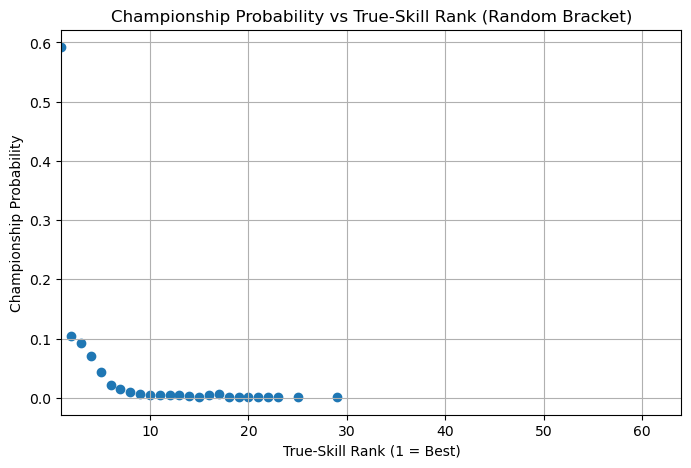

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plot_df_random = random_summary[random_summary["championship_probability"] > 0]

plt.scatter(
    plot_df_random["true_skill_rank"],
    plot_df_random["championship_probability"]
)

plt.xlim(1, 64)
plt.xlabel("True-Skill Rank (1 = Best)")
plt.ylabel("Championship Probability")
plt.title("Championship Probability vs True-Skill Rank (Random Bracket)")
plt.grid(True)
plt.show()

The one seed won most often yet again, but this time a lot more teams won, and it makes a cool little almost sigmoid looking graph from 2 to 10 where it levels out. 

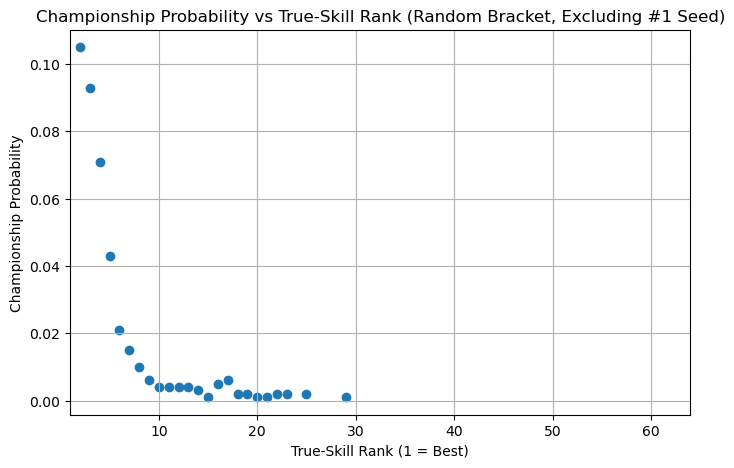

In [29]:
plt.figure(figsize=(8, 5))

plot_df_random_no1 = random_summary[
    (random_summary["championship_probability"] > 0) &
    (random_summary["true_skill_rank"] != 1)
]

plt.scatter(
    plot_df_random_no1["true_skill_rank"],
    plot_df_random_no1["championship_probability"]
)

plt.xlim(1, 64)
plt.xlabel("True-Skill Rank (1 = Best)")
plt.ylabel("Championship Probability")
plt.title("Championship Probability vs True-Skill Rank (Random Bracket, Excluding #1 Seed)")
plt.grid(True)
plt.show()

Both methods fewature an exponential decay curve that drops off sharply from the 1 seed, and are pretty similar. The biggest difference is that more teams managed to bag a championship in the random bracket than the seeded bracket, which makes sense. The one seed also experienced a drop from a 65% championship win percentage to a 59.2% championship win percentage, which is a decent dropoff. The seeded bracket is meant to reward teams for playing well in the regular season of a sports season, so that they always have easier matchups to start out with, compared to a randomly seeded bracket that could help the favorite by giving them multiple really easy teams in a row, but could also give them a very difficult opponent in the first round, making their run much more difficult. 

#### Question 2

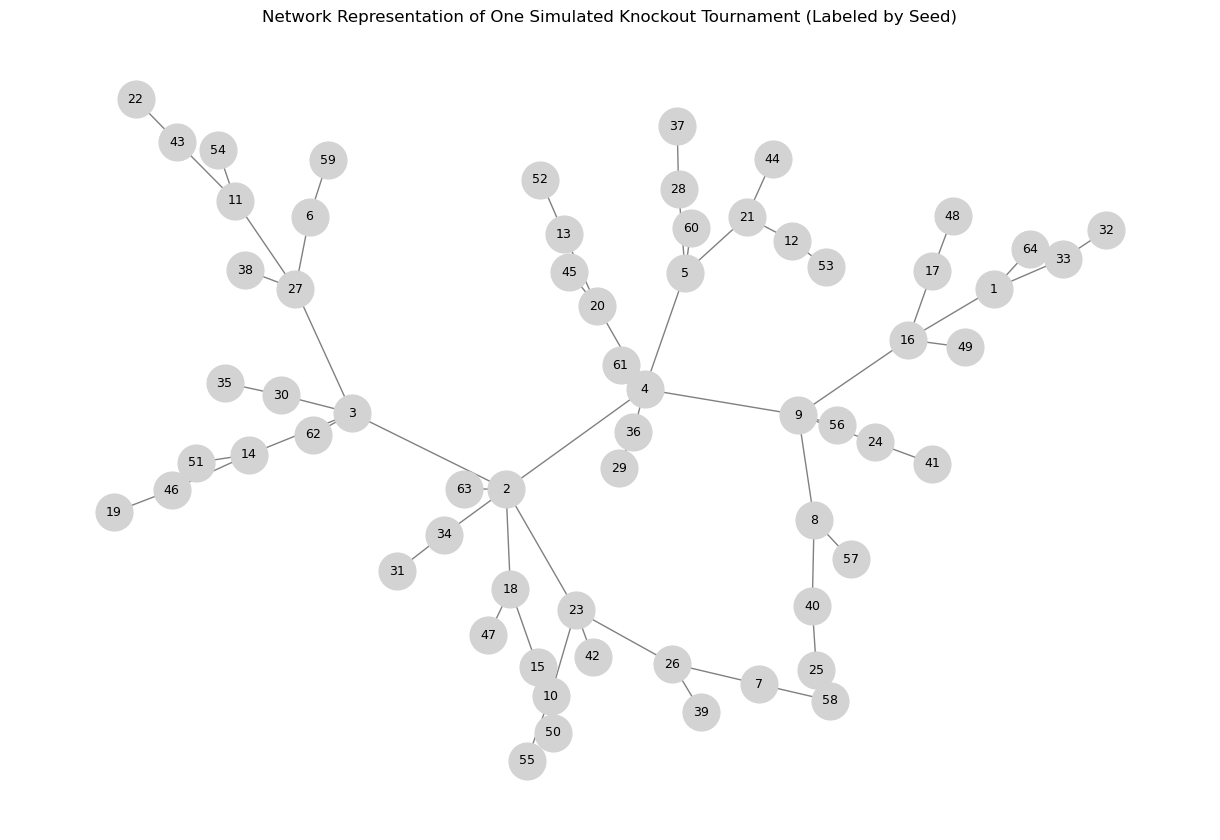

In [54]:
# Part a)
import networkx as nx

# Run one seeded tournament
rng = np.random.default_rng(55)
champion, match_log_df = run_knockout(teams_df, rng)

# Map team_id to seed from the tournament teams
teams_sorted = teams_df.sort_values("mu", ascending=False).reset_index(drop=True).copy()
teams_sorted["seed"] = teams_sorted.index + 1
team_to_seed = dict(zip(teams_sorted["team_id"], teams_sorted["seed"]))

# Create graph
G = nx.Graph()

# Add nodes using seed numbers
all_seeds = sorted(set(team_to_seed.values()))
G.add_nodes_from(all_seeds)

# Add edges using seeds instead of team ids
for _, row in match_log_df.iterrows():
    seedA = team_to_seed[row["teamA_id"]]
    seedB = team_to_seed[row["teamB_id"]]
    winner_seed = team_to_seed[row["winner_id"]]

    G.add_edge(
        seedA,
        seedB,
        round=row["round"],
        winner_seed=winner_seed
    )

# Draw graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightgray",
    edge_color="gray",
    node_size=700,
    font_size=9,
    font_color="black"
)

plt.title("Network Representation of One Simulated Knockout Tournament (Labeled by Seed)")
plt.show()

Note: ChatGPT was used to help create this network. 

Each team is attached to the team that beat them, which is pretty clear until the final 2 where it is difficult to tell who won between 2 and 4, 4 was the one who won. This graph shows that the 16 seed managed a pretty big upset over the number 1 overall seed in this tournament, which is extremely rare considering the 1 seed won 65% of the tournaments. 

### 2B - Swiss System

Preface: Im so sorry I didn't mean to write this much, you don't have to read all of this

The swiss system is a format that takes almost any number of teams, but most often 16, and pairs teams up based on their record. So if you win the first round, you are paired with another player who won the first round (for sone numbers of players, you may get someone who lost or someone who had a bye if they were the odd number out in the first round, but this only happens to one person). If you win the second round after winning the first round, you then get someone who is also 2-0, and if you are 1-1 you will get someone who is 1-1, etc. It has 2 main use cases in real life, both of which I am very familiar with. In Chess, swiss stages are often an entire tournament (Titled Tuesday on Chess.com is an example of this), and these swiss stages that are the whole tournament have a lot of players (TT has between 300-1000 players each event). But sometimes the swiss stage is then transitioned into a bracket. In chess, one event that does this is the Freestyle Chess Grand Slam Tour, but this is seen more often in Esports, which are the other main use case of swiss. I've followed Rocket League esports at various points, which has used swiss multiple times in the past. In the current season of RLCS, the swiss portion is used to reduce the open tournaments from 32 players down to 16. It works by splitting teams into 2 swiss groups of 16, which you exit the swiss stage when you either lose 3 matches (eliminated) or win 3 matches (qualified), every swiss stage lasts 5 rounds. The teams are then seeded into double elimination groups based on their record 1st, bucholz score 2nd (sum of all opponents match wins that you played against, ex: if you went 3-0 in the swiss stage, and the record of the 3 teams you beat were 1-3, 3-2, 3-1, your bucholz score would be 7. This is also used as a tiebreaker in chess tournaments, the one I know it is used in is Titled Tuesday.), game differential 3rd, and head to head 4th. In the past, they have also done tournaments where swiss is used to go from 16 to 8 teams, which are then put into a single elim bracket (RLCS fall 2021-22 was an example of this). Lastly, they have also done double swiss to go from 32 to 16, and then 16 to 8, then into a single elim bracket (RLCS Season X Fall North American Opens are an example of this). Sorry I've wrote so much and still only answered 2/3rds of this question, but to answer the last part, Swiss tournaments that are just swiss and no stage after work well when there is a large amount of players with a large skill gap between the worst players and the best players, and also a meaningful skill gap between the good players and the elite players. It tests a comptetitors ability to beat both players who are worse than you, and players that are on your skill level/slightly better, and the winner at the end will have earned it. It also gives lower rated players/lower ranked teams to get multiple games against better competition if they get off to a hot start, giving them good practice/experience for the future. Swiss into some sort of bracket I feel works best when you have a lot of variance, as it gives the top teams a chance to take an unexpected loss and still be okay. The main drawback of swiss into some sort of single elimination bracket, is that if you play really well and get the 1 or 2 seed, you can still run into an elite team who just had an off day but would maybe be favored against you tomorrow, this type of format doesn't reward top performers well enough. In my opinion, this could be fixed by having teams choose their opponent in order of seed, ie the 1 seed gets first pick between 5-8, 2nd place gets 2nd pick, etc. This would reward the top performers of the swiss stage, and also can create really cool storylines. For example, in the 2025 Freestyle Chess Tour finals, youngster Jakhovir Sindarov voluntarily chose the tournament 2nd favorite Hikaru Nakamura and preceded to beat him in the quarterfinals. A year later, Jakhovir Sindarov is currently having the greatest Candidates tournament since Bobby Fischer in the 60s and if he doesn't collapse in the 2nd half of the tournament he will be the challenger in the World Chess Championship. Since I've already wrote so much on this tangent I'll share my own personal experience in a swiss stage tournament, as I competed in multiple with my high school to determine our tournament team and ranking. As an underdog, it was pretty fun to play, and I managed to do quite well and place higher than I probably should've. As the favorite it was the most stressful competition I have ever been apart of, and I did well most of the time but it was so so so stressful. That is the end of my tangent on swiss style formats. 

Below is code for an example of what a 16 player, 4 round swiss stage (end goal being 1 overall winner), would function like. 

In [59]:
import random
import pandas as pd


def create_teams(num_teams):
    """
    Create a dataframe of teams for a Swiss tournament.
    """
    return pd.DataFrame({
        "team_id": list(range(1, num_teams + 1)),
        "wins": [0] * num_teams,
        "losses": [0] * num_teams,
        "points": [0] * num_teams,   # optional Swiss points system
        "bye_received": [False] * num_teams,
        "opponents": [[] for _ in range(num_teams)]
    })


def sort_standings(teams_df):
    """
    Sort teams by Swiss standings.
    """
    return teams_df.sort_values(
        by=["wins", "points", "team_id"],
        ascending=[False, False, True]
    ).reset_index(drop=True)


def assign_bye(teams_df):
    """
    If number of teams is odd, assign a bye to the lowest-ranked team
    who has not already received one.
    """
    if len(teams_df) % 2 == 0:
        return teams_df, None

    standings = sort_standings(teams_df)

    for i in range(len(standings) - 1, -1, -1):
        team_id = standings.loc[i, "team_id"]
        original_idx = teams_df.index[teams_df["team_id"] == team_id][0]

        if not teams_df.loc[original_idx, "bye_received"]:
            teams_df.loc[original_idx, "wins"] += 1
            teams_df.loc[original_idx, "points"] += 1
            teams_df.loc[original_idx, "bye_received"] = True
            return teams_df, team_id

    # fallback if everyone already had a bye
    team_id = standings.loc[len(standings) - 1, "team_id"]
    original_idx = teams_df.index[teams_df["team_id"] == team_id][0]
    teams_df.loc[original_idx, "wins"] += 1
    teams_df.loc[original_idx, "points"] += 1
    return teams_df, team_id


def pair_round(teams_df, bye_team=None):
    """
    Pair teams for one Swiss round based on current standings.
    Avoid repeat opponents when possible.
    """
    standings = sort_standings(teams_df)

    if bye_team is not None:
        standings = standings[standings["team_id"] != bye_team].reset_index(drop=True)

    unpaired = standings["team_id"].tolist()
    pairings = []

    while unpaired:
        team_a = unpaired.pop(0)

        # try to find first valid opponent not already played
        opponent_index = None
        team_a_idx = teams_df.index[teams_df["team_id"] == team_a][0]
        previous_opponents = teams_df.loc[team_a_idx, "opponents"]

        for i, team_b in enumerate(unpaired):
            if team_b not in previous_opponents:
                opponent_index = i
                break

        # if everyone remaining has already played team_a, just take first available
        if opponent_index is None:
            opponent_index = 0

        team_b = unpaired.pop(opponent_index)
        pairings.append((team_a, team_b))

    return pairings


def play_round(teams_df, pairings):
    """
    Simulate one round of matches.
    Winner is chosen randomly.
    """
    results = []

    for team_a, team_b in pairings:
        winner = random.choice([team_a, team_b])
        loser = team_b if winner == team_a else team_a

        winner_idx = teams_df.index[teams_df["team_id"] == winner][0]
        loser_idx = teams_df.index[teams_df["team_id"] == loser][0]

        teams_df.loc[winner_idx, "wins"] += 1
        teams_df.loc[winner_idx, "points"] += 1

        teams_df.loc[loser_idx, "losses"] += 1

        teams_df.at[winner_idx, "opponents"] = teams_df.at[winner_idx, "opponents"] + [loser]
        teams_df.at[loser_idx, "opponents"] = teams_df.at[loser_idx, "opponents"] + [winner]

        results.append((team_a, team_b, winner))

    return teams_df, results


def run_swiss_tournament(num_teams, num_rounds):
    """
    Run a full Swiss-system tournament.
    """
    teams_df = create_teams(num_teams)

    for round_num in range(1, num_rounds + 1):
        print(f"\n=== Round {round_num} ===")

        teams_df, bye_team = assign_bye(teams_df)
        if bye_team is not None:
            print(f"Bye: Team {bye_team}")

        pairings = pair_round(teams_df, bye_team=bye_team)
        print("Pairings:")
        for team_a, team_b in pairings:
            print(f"Team {team_a} vs Team {team_b}")

        teams_df, results = play_round(teams_df, pairings)

        print("Results:")
        for team_a, team_b, winner in results:
            print(f"Team {team_a} vs Team {team_b} -> Winner: Team {winner}")

        standings = sort_standings(teams_df)[["team_id", "wins", "losses", "points"]]
        print("\nStandings after round:")
        print(standings.to_string(index=False))

    return sort_standings(teams_df)


# Example usage
final_standings = run_swiss_tournament(num_teams=16, num_rounds=4)

print("\n=== Final Standings ===")
print(final_standings[["team_id", "wins", "losses", "points"]].to_string(index=False))


=== Round 1 ===
Pairings:
Team 1 vs Team 2
Team 3 vs Team 4
Team 5 vs Team 6
Team 7 vs Team 8
Team 9 vs Team 10
Team 11 vs Team 12
Team 13 vs Team 14
Team 15 vs Team 16
Results:
Team 1 vs Team 2 -> Winner: Team 1
Team 3 vs Team 4 -> Winner: Team 4
Team 5 vs Team 6 -> Winner: Team 6
Team 7 vs Team 8 -> Winner: Team 7
Team 9 vs Team 10 -> Winner: Team 10
Team 11 vs Team 12 -> Winner: Team 12
Team 13 vs Team 14 -> Winner: Team 13
Team 15 vs Team 16 -> Winner: Team 16

Standings after round:
 team_id  wins  losses  points
       1     1       0       1
       4     1       0       1
       6     1       0       1
       7     1       0       1
      10     1       0       1
      12     1       0       1
      13     1       0       1
      16     1       0       1
       2     0       1       0
       3     0       1       0
       5     0       1       0
       8     0       1       0
       9     0       1       0
      11     0       1       0
      14     0       1       0
      15  

In [ ]:
ChatGPT used to help generate this example swiss tournament

##### Question 3)

One dataset I have used before is Baseball Savant's statcast, found here: https://baseballsavant.mlb.com/statcast_search. You can get whatever baseball data your heart desires. In the past, I've done a project with my friend where we took all of the red sox and yankees pitcher data from the 2023-24 (I think?) season, and we turned it into a sankey diagram, which can be found here if you are curious https://github.com/millerliam/MLB-Pitch-Dashboard. One question that could be posed is, what attack zones yielded the best results for the batter when there were runners in scoring position and less than 2 strikes? Once that is answered, you could also say what players were the best at attacking said zones. Unit of analysis would be pitches that fit the criteria. The dependent variable is the attack zone, and the variables used as a metric of success would be a combination of XBA/XWOBA, Quality of Contact, Ideal Attack Angle, Runs on Play, Outs on Play, Pitch Result, and PA Result. Other people have used this data before, and all 30 MLB teams use this data. 

### Question 4)

I have watched Moneyball before, some of my favorite parts are them showing up to Scott Hatteberg's house, Billy firing the head scout and promoting some random guy, Billy calling pete late at night and telling him he bought him, the scene where Billy tells Art he traded Pena (and tells giambi hes traded), and the scene after Billy comes back from Boston where Pete throws a baseball at him and then shows him the clip of the guy trying to go to second base. 